# Data Load And Analysis

In [1]:
# Everytime reload the notebook, reload the modules
%load_ext autoreload
%autoreload 2

# Data load and split

import pandas as pd
import os

split_csv = pd.read_csv("data/CelebA1/Eval/list_eval_partition.csv", sep=" ")

train_csv = split_csv[split_csv["split_id"] == 0]
test_csv = split_csv[split_csv["split_id"] == 1]
val_csv = split_csv[split_csv["split_id"] == 2]

print(train_csv.head(10))

image_dir = "data/CelebA1/Img/img_align_celeba"

train_img_paths = train_csv["file_name"].apply(lambda x: os.path.join(image_dir, x))
test_img_paths = test_csv["file_name"].apply(lambda x: os.path.join(image_dir, x))
val_img_paths = val_csv["file_name"].apply(lambda x: os.path.join(image_dir, x))

# convert to list
train_img_paths = train_img_paths.tolist()
test_img_paths = test_img_paths.tolist()
val_img_paths = val_img_paths.tolist()

print(len(train_img_paths))
print(len(test_img_paths))
print(len(val_img_paths))

# compute porportion of each class
prop = split_csv["split_id"].value_counts(normalize=True)

print(prop)

result_dir = None


    file_name  split_id
0  000001.jpg         0
1  000002.jpg         0
2  000003.jpg         0
3  000004.jpg         0
4  000005.jpg         0
5  000006.jpg         0
6  000007.jpg         0
7  000008.jpg         0
8  000009.jpg         0
9  000010.jpg         0
162770
19867
19962
split_id
0    0.803410
2    0.098530
1    0.098061
Name: proportion, dtype: float64


In [2]:
# Load datasets
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from my_dataset import CustomImageDataset

BATCH_SIZE = 128
IMG_SIZE = (64, 64)

transform = transforms.Compose([
    transforms.CenterCrop((178, 178)),
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    # normalize to [-1, 1] for tanh activation
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


train_dataset = CustomImageDataset(train_img_paths, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = CustomImageDataset(val_img_paths, transform=transform)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = CustomImageDataset(test_img_paths, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(len(train_dataset), len(train_loader), len(train_loader)*BATCH_SIZE)

162770 1272 162816


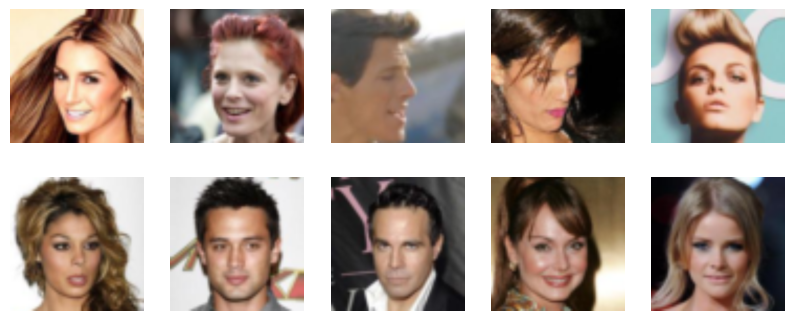

In [3]:
# Show example of images
import matplotlib.pyplot as plt

inv_transform = transforms.Compose([
    # denormalize
    transforms.Lambda(lambda x: (x * 0.5) + 0.5),
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),
])

# show image in 2*5 grid
plt.figure(figsize=(10, 4))

for i, image in enumerate(train_dataset):
    if i == 10:
        break
    img = inv_transform(image)
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.axis('off')
plt.show()



## Model Loading

In [4]:
import re
from pathlib import Path
import os
import json


def parse_result_dir_config(dir_path: str) -> dict:
    # check if there is hyperparameters.json file
    if os.path.exists(f"{result_dir}/hyperparameters.json"):
        with open(f"{result_dir}/hyperparameters.json", "r") as f:
            return json.load(f)

    RESULT_DIR_RE = re.compile(
        r"^results_(?P<model>.+?)_ImSize(?P<img>\d+)_Lat(?P<lat>\d+)(?P<rest>.*)$"
    )
    LOSS_CHOICES = {"H", "B", "PID", "Cyclical"}

    name = Path(dir_path).name
    match = RESULT_DIR_RE.match(name)
    if not match:
        raise ValueError(f"{name} is not a recognized results directory.")

    tokens = [tok for tok in match["rest"].split("_") if tok]
    loss_type = next((tok for tok in tokens if tok in LOSS_CHOICES), None)
    if not loss_type:
        raise ValueError("Loss type tag is missing in directory name.")
    tokens.remove(loss_type)

    cfg = {
        "model_name": match["model"],
        "image_size": (int(match["img"]), int(match["img"])),
        "latent_dim": int(match["lat"]),
        "loss_type": loss_type,
        "enable_perceptual_loss": False,
        "tvl_weight": 0.0,
        "lpips_weight": 0.0,
    }

    for tok in list(tokens):
        if tok.startswith("TVL"):
            cfg["tvl_weight"] = int(tok[3:]) / 1e4
            tokens.remove(tok)
        elif tok.startswith("LPIPS"):
            cfg["lpips_weight"] = int(tok[5:]) / 10.0
            cfg["enable_perceptual_loss"] = True
            tokens.remove(tok)

    if loss_type == "H":
        beta_tok = next((t for t in tokens if t.startswith("Beta")), None)
        if beta_tok:
            cfg["beta"] = float(beta_tok[4:])
    elif loss_type == "B":
        gamma_tok = next((t for t in tokens if t.startswith("G")), None)
        cap_tok = next((t for t in tokens if t.startswith("C")), None)
        if gamma_tok:
            cfg["gamma"] = float(gamma_tok[1:])
        if cap_tok:
            cfg["max_capacity"] = float(cap_tok[1:])
    elif loss_type == "PID":
        exp_tok = next((t for t in tokens if t.startswith("EXP")), None)
        if exp_tok:
            cfg["exp_kld_loss"] = float(exp_tok[3:])
    elif loss_type == "Cyclical":
        cfg["mode"] = "linear"
        for tok in tokens:
            if tok.startswith("MaxBeta"):
                cfg["max_beta"] = float(tok[7:])
            elif tok.startswith("Ratio"):
                cfg["ratio"] = int(tok[5:]) / 100.0
            elif tok.lower() in {"linear", "sigmoid"}:
                cfg["mode"] = tok.lower()

    return cfg


# Example usage
if not result_dir:
    result_dir = "results_beta_vae_ImSize64_Lat128_TVL10_LPIPS12_H_Beta1"

config = parse_result_dir_config(result_dir)
print(config)

{'model_name': 'beta_vae', 'image_size': 64, 'latent_dim': 128, 'loss_type': 'H', 'enable_perceptual_loss': True, 'tvl_weight': 0.001, 'lpips_weight': 1.2, 'beta': 1.0, 'hidden_dims': [32, 64, 128, 256, 512]}


In [31]:
from models.beta_vae import BetaVAE
from models.beta_tc_vae import BetaTCVAE
import torch
# Load model from directory


def load_model(model_dir: str, device=None):

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # parse model_dir to get model create parameters
    cfg = parse_result_dir_config(model_dir)

    model_name = cfg["model_name"]
    hidden_dims = cfg.get("hidden_dims", [32, 64, 128, 256, 512])
    if "hidden_dims" not in cfg:
        if cfg["image_size"] >= 128 or cfg["latent_dim"] >= 256:
            hidden_dims.append(1024)

    if model_name == "beta_vae":
        model = BetaVAE(
            in_channels=3,
            loss_type=cfg["loss_type"],
            gamma=cfg.get("gamma", 0),
            latent_dim=cfg["latent_dim"],
            hidden_dims=hidden_dims,
            image_size=(cfg["image_size"], cfg["image_size"]),
            beta=cfg.get("beta", 1),
            max_capacity=cfg.get("max_capacity", 0),
            exp_kld_loss=cfg.get("exp_kld_loss", 0),
            enable_perceptual_loss=cfg["enable_perceptual_loss"],
            lpips_weight=cfg["lpips_weight"],
            tvl_weight=cfg["tvl_weight"],
            total_steps=1,  # dummy value
            max_beta=cfg.get("max_beta", 1),
            ratio=cfg.get("ratio", 0.5),
            circular_mode=cfg.get("mode", "linear"),
        )
    else:
        model = BetaTCVAE(
            in_channels=3,
            latent_dim=cfg["latent_dim"],
            hidden_dims=hidden_dims,
            image_size=(cfg["image_size"], cfg["image_size"]),
            enable_perceptual_loss=cfg["enable_perceptual_loss"],
            lpips_weight=cfg["lpips_weight"],
            tvl_weight=cfg["tvl_weight"],
            
            anneal_steps=cfg.get("anneal_steps", 200),
            alpha=cfg.get("alpha", 1.0),
            beta=cfg.get("beta", 6.0),
            gamma=cfg.get("gamma", 1.0),
        )

    model_path = f"{model_dir}/best_{model_name}.pth"
    if not os.path.exists(model_path):
        model_path = f"{model_dir}/last_{model_name}.pth"
        print(f"Warning: best model not found, using last model")

    model.load_state_dict(torch.load(model_path))

    model.to(device)

    return model




In [109]:
result_dir = "results_beta_vae_ImSize64_Lat128_TVL10_LPIPS12_H_Beta1"
model = load_model(result_dir)

/home/supercomputing/miniconda3/envs/cv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/supercomputing/miniconda3/envs/cv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## Reconstruct and Sample

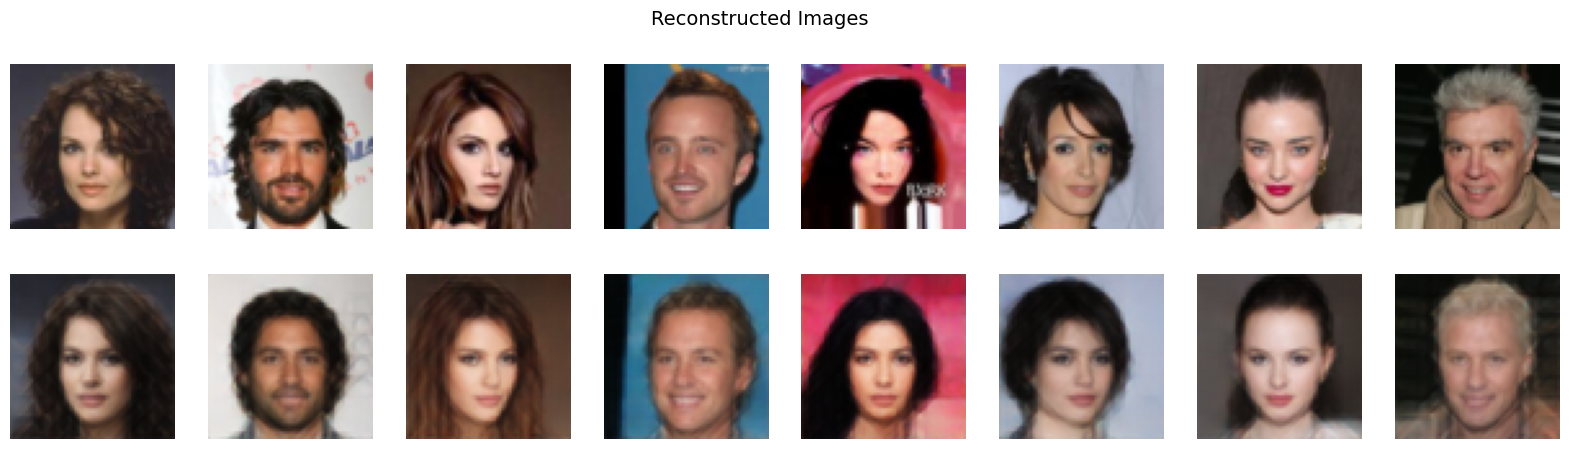

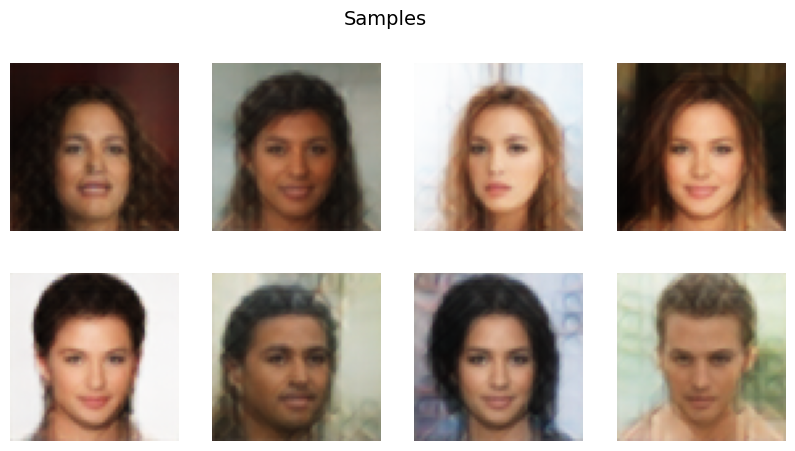

In [110]:
from models.base import BaseVAE

def reconstruct(model: BaseVAE, data_loader: DataLoader, device=None, rows:int =2, cols:int = 8):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.eval()
    
    # Number of images per set (original and reconstructed)
    num_images = (rows // 2) * cols
    
    recon_imgs = []
    with torch.no_grad():
        # encode and decode batch
        for data in data_loader:
            # take only num_images from the batch
            data = data[:num_images].to(device)

            res = model.forward(data)
            recons = res[0]
            
            # Interleave: for each row of originals, follow with row of reconstructions
            # [orig0-9, recon0-9, orig10-19, recon10-19, ...]
            for i in range(0, num_images, cols):
                recon_imgs.extend(data[i:i+cols].cpu())
                recon_imgs.extend(recons[i:i+cols].cpu())
            break
    
    # denormalize from [-1, 1] to [0, 1] and convert to numpy H*W*C
    recon_imgs = [(img * 0.5 + 0.5).clamp(0, 1).numpy().transpose(1, 2, 0) for img in recon_imgs]

    return recon_imgs

def sample(model: BaseVAE, device=None, rows:int =2, cols:int = 8):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.eval()
    
    samples = []
    with torch.no_grad():
        for i in range(rows * cols):
            z = torch.randn(1, model.latent_dim).to(device)
            sample = model.decode(z).cpu().squeeze(0)
            # denormalize from [-1, 1] to [0, 1] and convert to numpy H*W*C
            sample = (sample * 0.5 + 0.5).clamp(0, 1).numpy().transpose(1, 2, 0)
            samples.append(sample)
    return samples

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

recon_imgs = reconstruct(model, test_loader, device=device)
samples = sample(model, device=device, rows=1)

# display recon_imgs
fig = plt.figure(figsize=(20, 5))
for i in range(len(recon_imgs)):
    plt.subplot(2, 8, i + 1)
    plt.imshow(recon_imgs[i])
    plt.axis('off')

# plt.tight_layout()
fig.suptitle("Reconstructed Images", y=0.98, fontsize=14)
plt.show()

# display samples
fig = plt.figure(figsize=(10, 5))
for i in range(len(samples)):
    plt.subplot(2, 4, i + 1)
    plt.imshow(samples[i])
    plt.axis('off')
# plt.tight_layout()
fig.suptitle("Samples", y=0.98, fontsize=14)
plt.show()
    


# Latent Analsys

Max KLD in a dimension: 2.6254
Min KLD in a dimension: 0.0010
Active Dimensions (>0.1): 49 / 128
Dead Dimensions (<0.01): 71 / 128
10 Most Active Dimensions: [110, 18, 54, 25, 56, 89, 122, 47, 102, 3]
10 Least Active Dimensions: [99, 82, 21, 70, 81, 38, 29, 67, 30, 61]


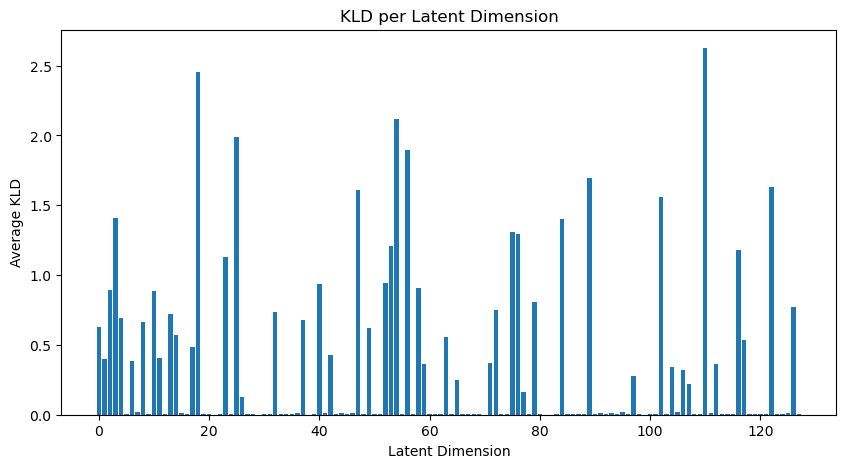

In [111]:
# Latent analysis
# 1. activat dim number compute

def latent_active_dim_analysis(model: BetaVAE, test_loader: DataLoader, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    data = next(iter(test_loader))  # 取一个 Batch
    data = data.to(device)

    model.eval()

    with torch.no_grad():
        mu, log_var = model.encode(data)  # 获取 mu 和 logvar

        # 计算每一维的平均 KLD (注意这里 dim=0，保留 dim=1 的 256 个维度)
        # 公式: -0.5 * mean(1 + logvar - mu^2 - exp(logvar))
        kld_per_dim = -0.5 * \
            torch.mean(1 + log_var - mu ** 2 - log_var.exp(), dim=0)

        print(f"Max KLD in a dimension: {kld_per_dim.max().item():.4f}")
        print(f"Min KLD in a dimension: {kld_per_dim.min().item():.4f}")

        # 统计有多少个“活跃”维度 (阈值设为 0.1)
        active_dims = (kld_per_dim > 0.1).sum().item()
        print(f"Active Dimensions (>0.1): {active_dims} / {model.latent_dim}")

        # 统计有多少个死亡维度 (阈值设为 0.01)
        dead_dims = (kld_per_dim < 0.01).sum().item()
        print(f"Dead Dimensions (<0.01): {dead_dims} / {model.latent_dim}")

        # get 10 most active dimensions
        most_active_dims = torch.topk(kld_per_dim, 10).indices.tolist()
        print(f"10 Most Active Dimensions: {most_active_dims}")

        # get 10 least active dimensions
        least_active_dims = torch.topk(-kld_per_dim, 10).indices.tolist()
        print(f"10 Least Active Dimensions: {least_active_dims}")

    return most_active_dims, least_active_dims, kld_per_dim.cpu().numpy()


top_10_dims, bottom_10_dims, kld_per_dim = latent_active_dim_analysis(
    model, test_loader)

plt.figure(figsize=(10, 5))
plt.bar(range(model.latent_dim), kld_per_dim)
plt.xlabel('Latent Dimension')
plt.ylabel('Average KLD')
plt.title('KLD per Latent Dimension')
plt.show()

## Compare Z With Normal Distribution

Extracting latent vectors from dataloader...
Calculating KL Divergence stats...
Computing PCA...
Computing KDE for visualization...


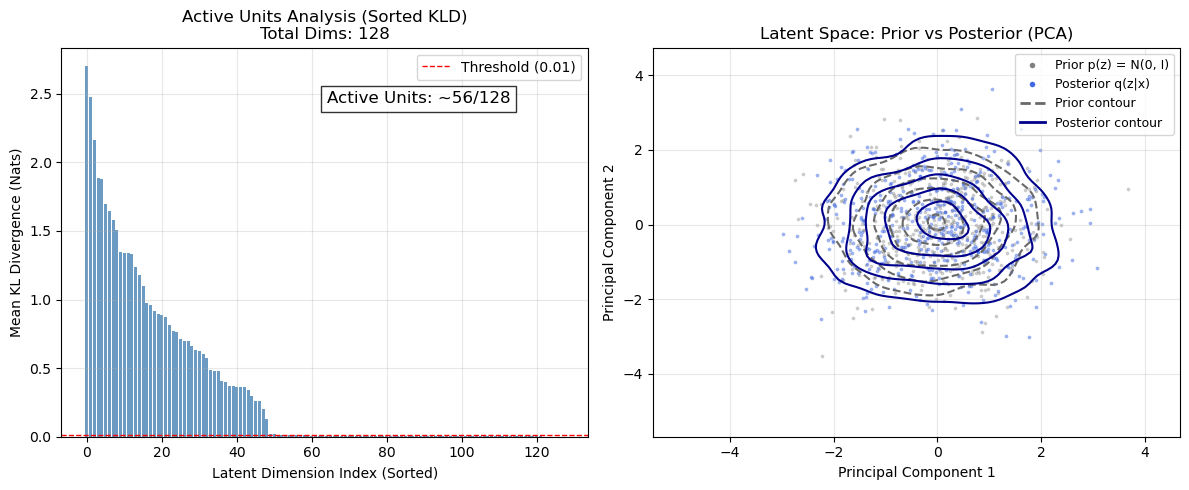

------------------------------
Latent Space Statistics:
  - Total Dimensions: 128
  - Active Units Count (KLD > 0.01): 56
  - Max KLD (Single Dim): 2.7002
  - Min KLD (Single Dim): 0.0011
------------------------------


In [112]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader
from scipy.stats import gaussian_kde

def analyze_latent_space(model, dataloader, device='cuda'):
    """
    Analyzes the latent space of the trained VAE.
    1. Plots the KL Divergence per dimension (Active Units).
    2. Visualizes the latent space using PCA against a Standard Normal distribution.
    """
    model.eval()
    
    # Containers for latent variables
    all_mus = []
    all_logvars = []
    
    print("Extracting latent vectors from dataloader...")
    
    # Disable gradient calculation for inference
    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            # Handle different dataloader output formats
            # Assuming batch is [img, label] or just img
            if isinstance(batch, (list, tuple)):
                imgs = batch[0]
            else:
                imgs = batch
            
            imgs = imgs.to(device)
            
            # Forward pass
            # NOTE: Adjust indices based on your model's return signature
            # Example: returns [recons, input, mu, log_var]
            results = model(imgs)
            mu = results[2]
            log_var = results[3]
            
            # Move to CPU and convert to numpy
            all_mus.append(mu.cpu().numpy())
            all_logvars.append(log_var.cpu().numpy())
            
            # Optional: Break early for large datasets to save time
            if i > 50: 
                break 

    # Concatenate all batches
    all_mus = np.concatenate(all_mus, axis=0)           # Shape: [N_samples, latent_dim]
    all_logvars = np.concatenate(all_logvars, axis=0)   # Shape: [N_samples, latent_dim]
    
    n_samples, n_features = all_mus.shape
    
    # -------------------------------------------------------
    # Analysis 1: KL Divergence per Dimension (Active Units)
    # Formula: KLD = -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
    # -------------------------------------------------------
    print("Calculating KL Divergence stats...")
    
    # Calculate analytical KLD for each sample and each dimension
    kld_per_sample_dim = -0.5 * (1 + all_logvars - all_mus**2 - np.exp(all_logvars))
    
    # Average across the batch dimension to get mean KLD per latent dimension
    mean_kld_per_dim = np.mean(kld_per_sample_dim, axis=0) # Shape: [latent_dim]
    
    # Sort indices to make the plot easier to read (from most active to least active)
    sorted_indices = np.argsort(mean_kld_per_dim)[::-1]
    sorted_kld = mean_kld_per_dim[sorted_indices]
    
    # Define a threshold to count "active" units (e.g., KLD > 0.01 nats)
    active_threshold = 0.01
    active_count = np.sum(mean_kld_per_dim > active_threshold)
    
    # -------------------------------------------------------
    # Analysis 2: PCA Visualization (Real z vs Standard Normal)
    # -------------------------------------------------------
    print("Computing PCA...")
    
    # Generate samples from standard normal distribution N(0, I)
    standard_normal_samples = np.random.normal(0, 1, (n_samples, n_features))
    
    # Initialize PCA
    pca = PCA(n_components=2)
    
    # Fit PCA on the VAE's encoded mu vectors
    mus_pca = pca.fit_transform(all_mus)
    
    # Transform standard normal samples into the SAME PCA space
    normal_pca = pca.transform(standard_normal_samples)
    
    # -------------------------------------------------------
    # Plotting
    # -------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot 1: Active Units
    axes[0].bar(range(n_features), sorted_kld, color='steelblue', alpha=0.8)
    axes[0].set_title(f'Active Units Analysis (Sorted KLD)\nTotal Dims: {n_features}')
    axes[0].set_xlabel('Latent Dimension Index (Sorted)')
    axes[0].set_ylabel('Mean KL Divergence (Nats)')
    axes[0].axhline(y=active_threshold, color='red', linestyle='--', linewidth=1, label=f'Threshold ({active_threshold})')
    axes[0].text(n_features * 0.5, np.max(sorted_kld) * 0.9, 
                 f'Active Units: ~{active_count}/{n_features}', fontsize=12, 
                 bbox=dict(facecolor='white', alpha=0.8))
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Create shared axis limits for PCA plots
    all_points = np.vstack([mus_pca, normal_pca])
    x_min, x_max = all_points[:, 0].min() - 1, all_points[:, 0].max() + 1
    y_min, y_max = all_points[:, 1].min() - 1, all_points[:, 1].max() + 1
    
    # Create grid for KDE contours
    xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    
    # Compute KDE for both distributions (using ALL samples)
    print("Computing KDE for visualization...")
    kde_vae = gaussian_kde(mus_pca.T)
    kde_normal = gaussian_kde(normal_pca.T)
    
    z_vae = np.reshape(kde_vae(positions).T, xx.shape)
    z_normal = np.reshape(kde_normal(positions).T, xx.shape)
    
    # Plot 2: Overlapped Prior and Posterior
    ax = axes[1]
    
    # Subsample points for cleaner visualization (but KDE uses all samples)
    display_samples = min(500, n_samples)
    display_idx = np.random.choice(n_samples, display_samples, replace=False)
    
    # Scatter points (prior in gray, posterior in blue) - subsampled for display
    ax.scatter(normal_pca[display_idx, 0], normal_pca[display_idx, 1], alpha=0.3, c='gray', s=12, marker='.', label='Prior p(z) samples')
    ax.scatter(mus_pca[display_idx, 0], mus_pca[display_idx, 1], alpha=0.4, c='royalblue', s=12, marker='.', label='Posterior q(z|x) samples')
    
    # Contours for both distributions
    ax.contour(xx, yy, z_normal, levels=6, colors='dimgray', linestyles='--', linewidths=1.5)
    ax.contour(xx, yy, z_vae, levels=6, colors='darkblue', linestyles='-', linewidths=1.5)
    
    # Add legend with proxy artists for contours
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='.', color='w', markerfacecolor='gray', markersize=10, label='Prior p(z) = N(0, I)'),
        Line2D([0], [0], marker='.', color='w', markerfacecolor='royalblue', markersize=10, label='Posterior q(z|x)'),
        Line2D([0], [0], color='dimgray', linestyle='--', linewidth=2, label='Prior contour'),
        Line2D([0], [0], color='darkblue', linestyle='-', linewidth=2, label='Posterior contour')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
    
    ax.set_title('Latent Space: Prior vs Posterior (PCA)', fontsize=12)
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print Statistics
    print("-" * 30)
    print("Latent Space Statistics:")
    print(f"  - Total Dimensions: {n_features}")
    print(f"  - Active Units Count (KLD > {active_threshold}): {active_count}")
    print(f"  - Max KLD (Single Dim): {np.max(mean_kld_per_dim):.4f}")
    print(f"  - Min KLD (Single Dim): {np.min(mean_kld_per_dim):.4f}")
    print("-" * 30)

    return mean_kld_per_dim, sorted_kld, sorted_indices

# Example usage:
mean_kld_per_dim, sorted_kld, sorted_indices = analyze_latent_space(model, val_loader, device='cuda')

## Latent Traversal

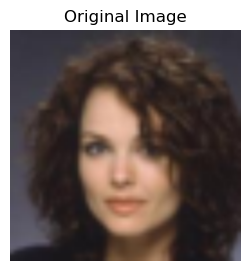

In [113]:
# Show latent traversals
import numpy as np


def latent_traversal(model: BetaVAE, z: torch.Tensor, dim: int, num_steps: int = 10, step_size: float = 3.0, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.eval()
    with torch.no_grad():
        # Prepare traversal vectors
        traversal_vectors = []
        alpha_values = np.linspace(-step_size, step_size, num_steps)
        # add 0 in the middle if not present
        if 0.0 not in alpha_values:
            alpha_values = np.sort(np.append(alpha_values, 0.0))
        for alpha in alpha_values:
            z_new = z.clone()
            z_new[0, dim] = alpha
            traversal_vectors.append(z_new)

        # Shape: (num_steps, latent_dim)
        traversal_vectors = torch.cat(traversal_vectors, dim=0)

        # Decode all traversal vectors
        reconstructed_images = model.decode(
            traversal_vectors)  # Shape: (num_steps, C, H, W)

    return reconstructed_images.cpu(), alpha_values


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Get a random latent vector from test set
data = next(iter(test_loader))
data = data.to(device)


# show the original image
original_image = inv_transform(data[0].cpu())
plt.figure(figsize=(3, 3))
plt.imshow(original_image)
plt.axis('off')
plt.title('Original Image')
plt.show()

### Top 10 activate latent dims

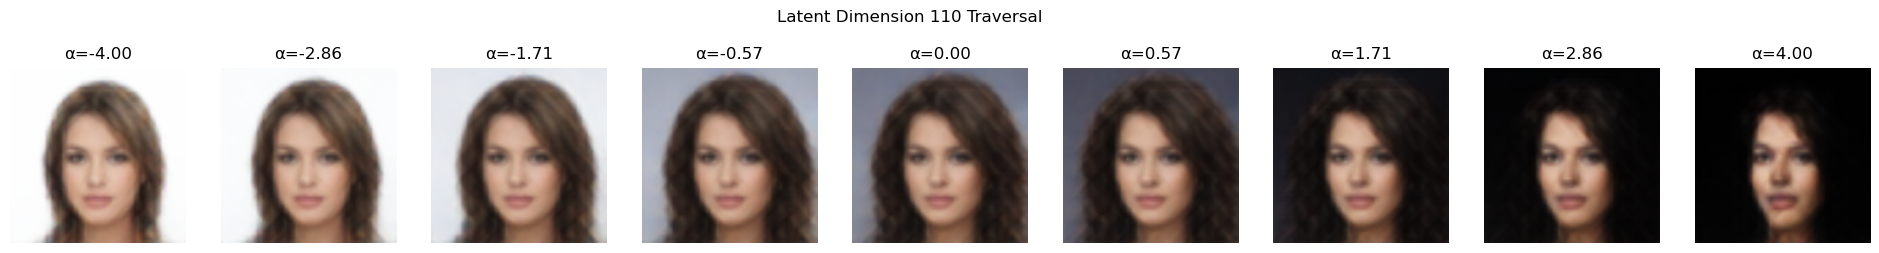

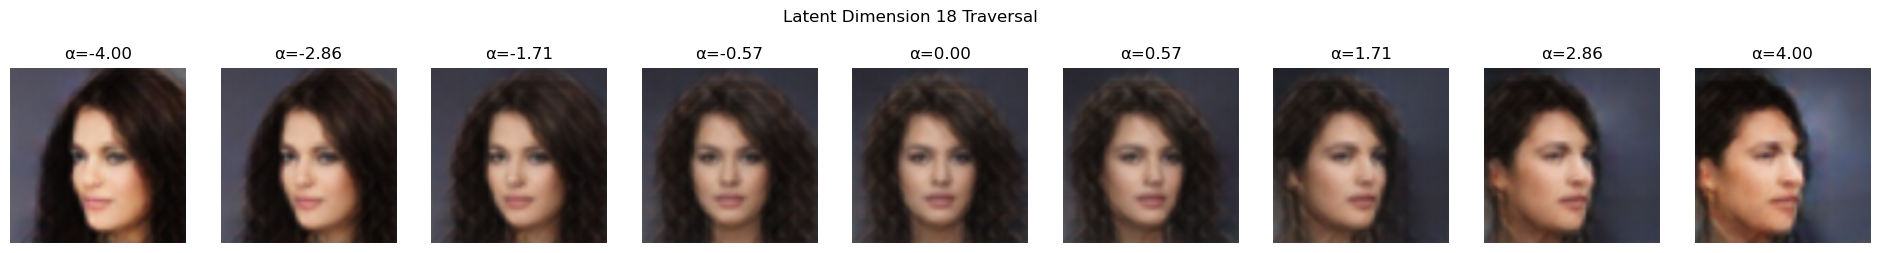

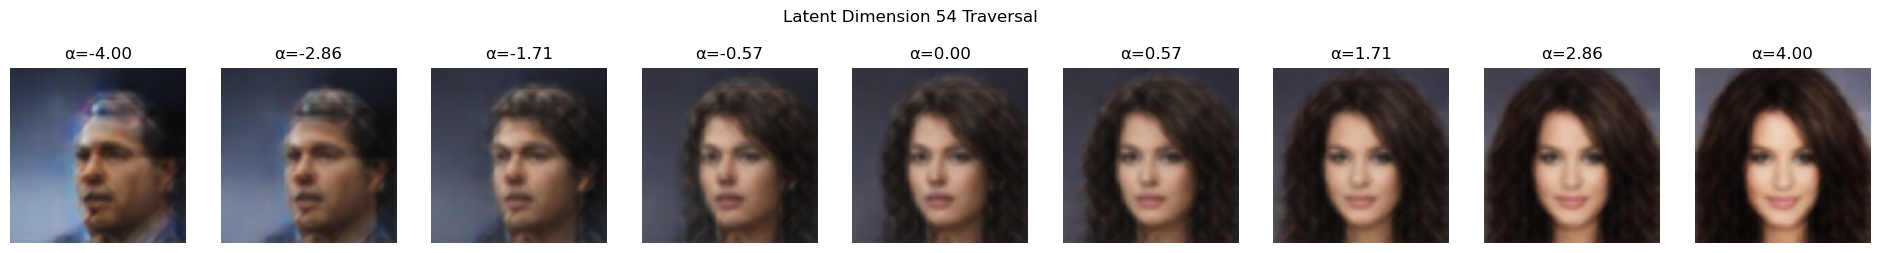

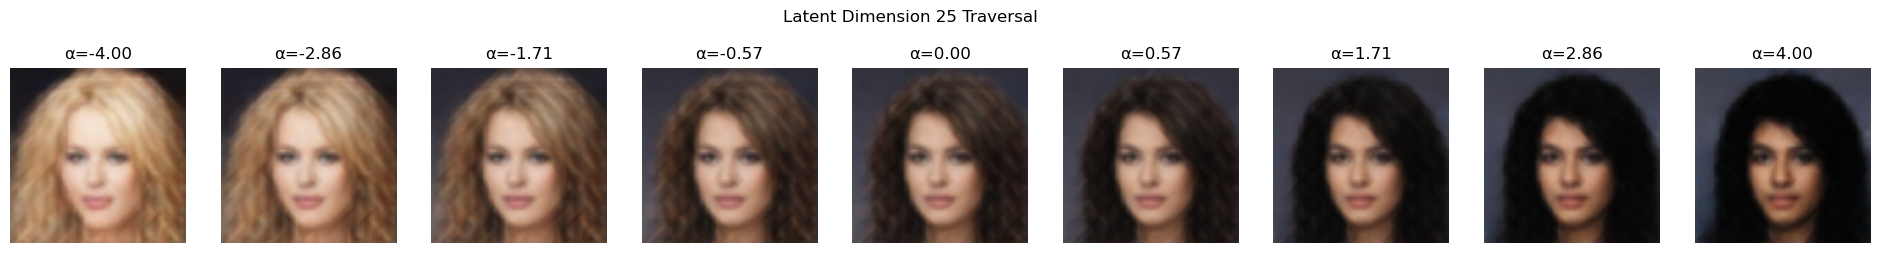

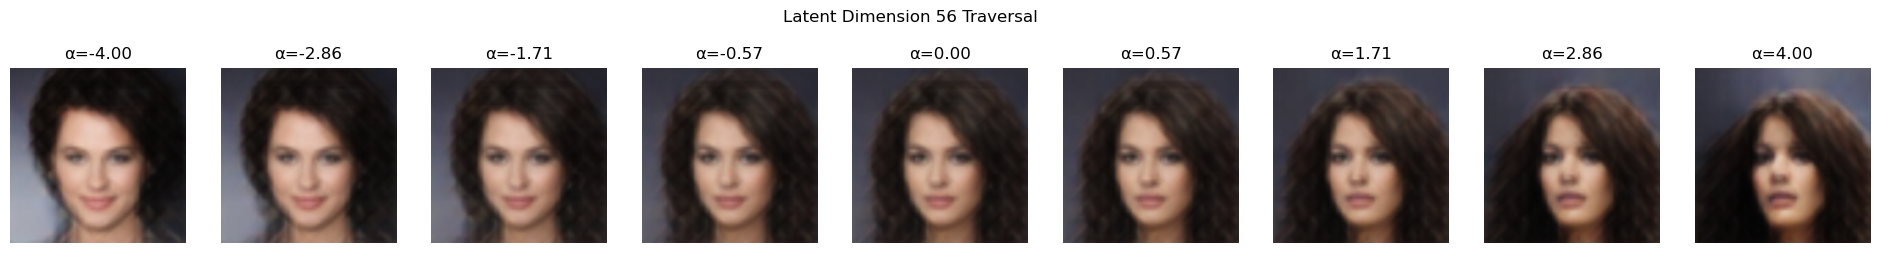

In [114]:
# Show traversal for top 3 active dimensions

model.eval()
with torch.no_grad():
    mu, log_var = model.encode(data)
    # sample z from mu
    z = mu[0:1, :]

for dim in sorted_indices[:5]:
    recon_images, alpha_values = latent_traversal(
        model, z, dim, num_steps=8, step_size=4.0, device=device)

    # Plot the traversal images
    plt.figure(figsize=(24, 3))
    for i in range(recon_images.size(0)):
        plt.subplot(1, recon_images.size(0), i + 1)
        img = inv_transform(recon_images[i])
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'α={alpha_values[i]:.2f}')
    plt.suptitle(f'Latent Dimension {dim} Traversal')
    plt.show()

### 10 Dead dims

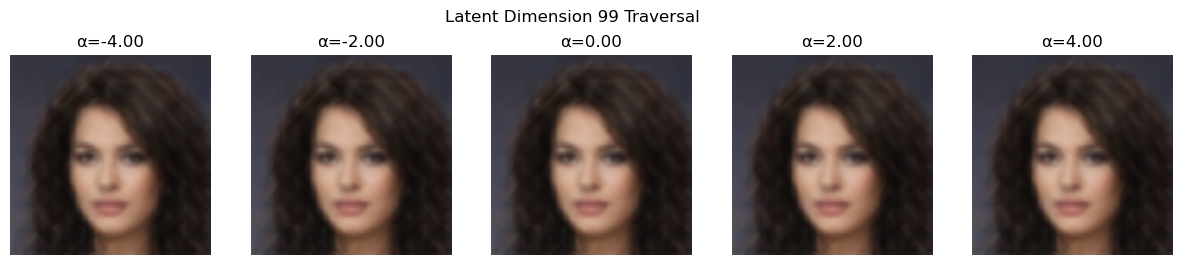

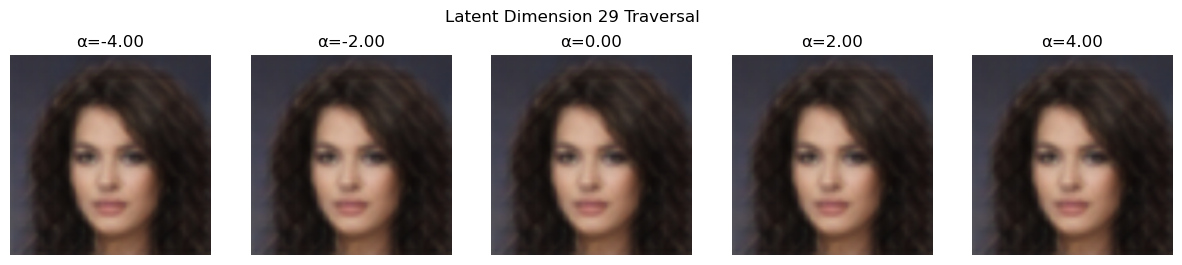

In [115]:
# Show traversal for top 3 active dimensions
for dim in sorted_indices[-1:-3:-1]:
    recon_images, alpha_values = latent_traversal(
        model, z, dim, num_steps=5, step_size=4.0, device=device)

    # Plot the traversal images
    plt.figure(figsize=(15, 3))
    for i in range(recon_images.size(0)):
        plt.subplot(1, recon_images.size(0), i + 1)
        img = inv_transform(recon_images[i])
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'α={alpha_values[i]:.2f}')
    plt.suptitle(f'Latent Dimension {dim} Traversal')
    plt.show()

## Latent Interpolation

In [116]:
# interpolation between two images
def interpolate_latent_space(model: BetaVAE, img1: torch.Tensor, img2: torch.Tensor, num_steps: int = 10, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.eval()
    with torch.no_grad():
        mu1, log_var1 = model.encode(img1.unsqueeze(0).to(device))
        mu2, log_var2 = model.encode(img2.unsqueeze(0).to(device))

        z1 = mu1
        z2 = mu2

        interpolated_images = []
        alpha_values = np.linspace(0, 1, num_steps)

        for alpha in alpha_values:
            z_new = (1 - alpha) * z1 + alpha * z2
            recon_img = model.decode(z_new)
            interpolated_images.append(recon_img.cpu())

        # Shape: (num_steps, C, H, W)
        interpolated_images = torch.cat(interpolated_images, dim=0)

    return interpolated_images, alpha_values

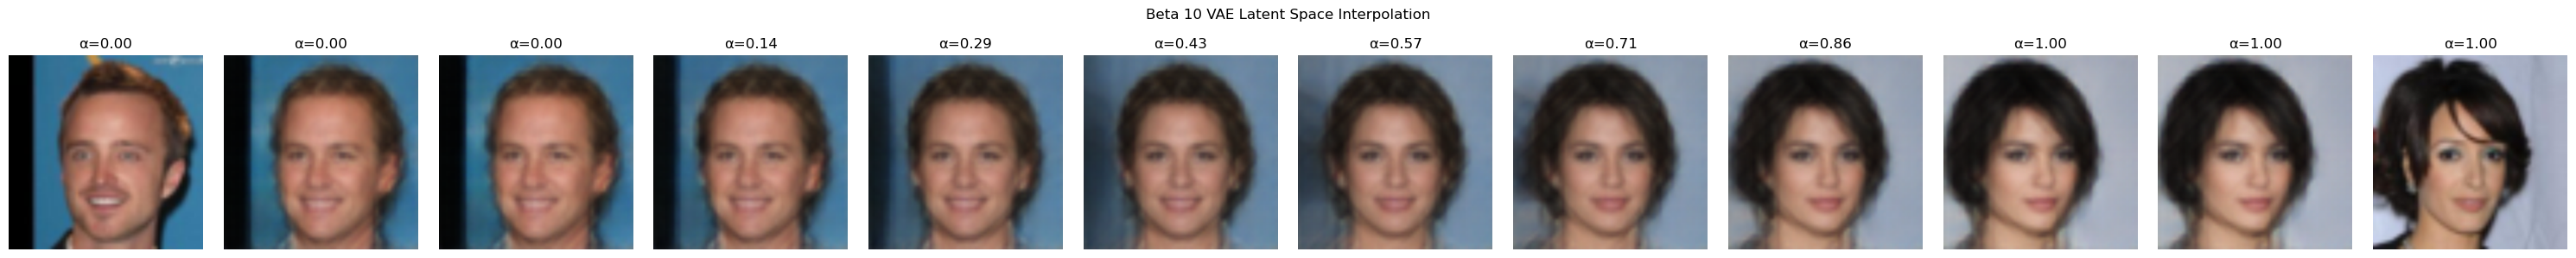

In [117]:
# show interpolation between two random images from test set
data_iter = iter(test_loader)
data = next(data_iter)
img1 = data[3]
img2 = data[5]

interpolated_images, alpha_values = interpolate_latent_space(
    model, img1, img2, num_steps=8, device=device)

# get recon of img1 and img2
recon_img1 = model.decode(model.encode(img1.unsqueeze(0).to(device))[0]).cpu()
recon_img2 = model.decode(model.encode(img2.unsqueeze(0).to(device))[0]).cpu()

# put recon_img1 at the beginning and recon_img2 at the end
interpolated_images = torch.cat([img1.unsqueeze(
    0), recon_img1, interpolated_images, recon_img2, img2.unsqueeze(0)], dim=0)
alpha_values = np.concatenate(([0.0, 0.0], alpha_values, [1.0, 1.0]))

# Plot the interpolation images
plt.figure(figsize=(30, 3))
for i in range(interpolated_images.size(0)):
    plt.subplot(1, interpolated_images.size(0), i + 1)
    img = inv_transform(interpolated_images[i])
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'α={alpha_values[i]:.2f}')
plt.suptitle('Beta 10 VAE Latent Space Interpolation')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()